# 2.1 Simframe

[Simframe](https://simframe.readthedocs.io/en/latest/) is a Python framework for scientific simulations. Since DustPy is based on Simframe this notebook will be a short and concise introduction on the usage and philosophy of Simframe.

Simframe allows you to easily integrate differential equations by simply providing a function returning the derivative of a quantity. The advantage is that you do not have to care about peripherals such as organizing the structure of your project or writing and reading data files. These things will be dealt by Simframe under the hood.

Consider the following simple problem that we want to solve. Take the differential equation

$\Large \frac{\mathrm{d}}{\mathrm{d}t} Y = -bY$

with the initial condition 

$\Large Y\left( t=0 \right) = A$.

The solution of this problem is known as

$\Large Y\left( t \right) = A  e^{-bt}$.

Additionally, we do not only want to integrate the quantity $Y$, but we want to also compute the quantity $T$, which is derived from $Y$ with

$\Large T = - \frac{1}{b} \log \frac{Y}{A}$,

This has the simply solution $T=t$ which we can compare later.

## Setting up the model

In the first step we create a Simframe object, which is an empty frame which needs to be filled by us.

In [1]:
from simframe import Frame

In [2]:
sim = Frame(description="Simple example")

In [3]:
sim

Frame (Simple example)
----------------------
    Integrator   : not specified
    Writer       : not specified

### Structuring the simulation frame

In the next step we create a group to store the simulation parameters $A$, $b$, as well as our desired time step of the integration $\Delta t$.

In [4]:
sim.addgroup("pars", description="Simulation parameters");

In [5]:
sim

Frame (Simple example)
----------------------
    pars         : Group (Simulation parameters)
  -----
    Integrator   : not specified
    Writer       : not specified

Then we add the parameters to our new group.

In [6]:
sim.pars.addfield("A", 10., description="Initial value of Y", constant=True);
sim.pars.addfield("b", 1., description="Decay rate", constant=True);
sim.pars.addfield("dt", 0.5, description="Time step");

In [7]:
sim.pars

Group (Simulation parameters)
-----------------------------
    A            : Field (Initial value of Y), constant
    b            : Field (Decay rate), constant
    dt           : Field (Time step)
  -----

These parameters can be easily addressed just like NumPy arrays.

In [8]:
sim.pars.A

10.0

In fact, they are NumPy arrays.

In [9]:
import numpy as np

In [10]:
isinstance(sim.pars.A, np.ndarray)

True

### Adding the integration variable

Our model now needs the integration variable $t$ which we add in this step to the simulation frame.

In [11]:
sim.addintegrationvariable("t", 0., description="Time");

In [12]:
sim

Frame (Simple example)
----------------------
    pars         : Group (Simulation parameters)
  -----
    t            : IntVar (Time), Integration variable
  -----
    Integrator   : not specified
    Writer       : not specified

The integration variable needs two additional pieces of information:  
First, it needs a prescription to derive the time step it should take from the current state of the simulation frame to the next. And second, it needs to know when to write output files.

To compute the time step we have to provide a function that takes the simulation frame as input and returns the timestep. In this example we simply want to return the time step we have stored previously in the parameters group.

In [13]:
def dt(sim):
    return sim.pars.dt

This function it then assigned to the so-called "updater" of the integration variable, because it tells the variable how to advance itself during an integration step. 

In [14]:
sim.t.updater = dt

Next we need to tell the integration variable at which values Simframe should write output files. The final value is also the final time of the simulation.

In [15]:
sim.t.snapshots = np.arange(0., 11., 1.)

### Adding fields to the simulation frame

Next we are going to add fields for the variables $Y$ and $T$ and initialize them with their respective values.

Both are conceptionally different: $Y$ will be integrated along the way. $T$ will be derived from the values of $Y$.

In [16]:
sim.addfield("Y", sim.pars.A, description="Integrated variable");
sim.addfield("T", 0., description="Derived variable");

In [17]:
sim

Frame (Simple example)
----------------------
    pars         : Group (Simulation parameters)
  -----
    t            : IntVar (Time), Integration variable
    T            : Field (Derived variable)
    Y            : Field (Integrated variable)
  -----
    Integrator   : not specified
    Writer       : not specified

In the case of $T$ we have to provide a function that takes the simulation frame as input and returns the new values of the variable.

In [18]:
def T(sim):
    """
    Function to compute `T` from `Y` and `b`.
    
    This should return the value of the integration variable of the integration is accurate.
    """
    return -np.log(sim.Y/sim.pars.A) / sim.pars.b

As previously, this function needs to be added to the updater of the field.

In [19]:
sim.T.updater = T

Additionally, we need to tell Simframe that it has to update this field once after every integration step. This can be done by providing a list with the field names which shall be updated in the desired order to the updater of the simulation frame. In this case we only have one field $T$ to be updated.

In [20]:
sim.updater = ["T"]

We can inspect the updaters which are assinged to fields and groups.

In [21]:
sim.updater

Heartbeat
---------

Systole:  None
Updater:  list_updater
Diastole: None

Docstrings
----------

Systole:
The type of the None singleton.

Updater:
The attributes in this group are updated in the order: 
['T'].

Diastole:
The type of the None singleton.

Here Simframe tells us that we have assigned a list updater to the parent simulation frame, which is updating the field $T$.

Additionally, there is information about a so-called systole and diastole. The systole is a function that is executed before the updating step, while the diastole is a function that is executed afterward. In our case we have not assigned a systole nor diastole.

We can furthermore inspect the updater of our field $T$.

In [22]:
sim.T.updater

Heartbeat
---------

Systole:  None
Updater:  <function T at 0x7ff20508df30>
Diastole: None

Docstrings
----------

Systole:
The type of the None singleton.

Updater:

Function to compute `T` from `Y` and `b`.

This should return the value of the integration variable of the integration is accurate.


Diastole:
The type of the None singleton.

Here Simframe tell us that we have assigned a function and is printing the its docstring.  
But we can also go deeper and let it display the Python source code of the function.

In [23]:
sim.T.updater.updater

Updater
-------

Signature: T(sim)
Source:
def T(sim):
    """
    Function to compute `T` from `Y` and `b`.

    This should return the value of the integration variable of the integration is accurate.
    """
    return -np.log(sim.Y/sim.pars.A) / sim.pars.b

File: /scratch-local/slurm-job-tmp-14297628/ipykernel_282/199005392.py
Type: function

This only works on the uppermost level. If our function is calling another function, maybe even in another language, it cannot be displayed here.

### Adding differential equations

The field $Y$ is not updated, but integrated. We therefore have to provide a function that returns the derivative of the field. This function needs in addition to the simulation frame also the integration variable and the field itself as input parameters.

In [24]:
def dYdt(sim, t, Y):
    return -sim.pars.b*Y

Instead of adding this function the updater, we have to add it to the "differentiator" of the field.

In [25]:
sim.Y.differentiator = dYdt

### Setting up the integrator

In the next step we need to add an integrator to the simulation, which tells Simframe what needs to be integrated and how to do it. The integrator needs to be initialized with the integration variable that is relevant for this problem.

In [26]:
from simframe import Integrator

In [27]:
sim.integrator = Integrator(sim.t)

And we need to give the integrator a list of integration instructions which tell it, what variable needs to be integrated with which integration scheme. In this example we are using a simple explicit Euler first order scheme.

In [28]:
from simframe import Instruction
from simframe import schemes

In [29]:
sim.integrator.instructions = [
    Instruction(schemes.expl_1_euler, sim.Y),
]

Now Simframe would be able to tell us the derivative of $Y$ with

In [30]:
sim.Y.derivative()

-10.0

### Configuring the writer

In the last step we can tell Simframe how to write output files. This is not strictly necessary. We could also run the simulation without writing any files. In this example we want to write output files in the *.hdf5 file format.

In [31]:
from simframe import writers

In [32]:
sim.writer = writers.hdf5writer()

We change the name of the datadirectory and allow Simframe to overwrite existing files in case they exist in the data directory.

In [33]:
sim.writer.datadir = "2.1_simframe"
sim.writer.overwrite = True

## Running the simulation

The simulation frame is now fully configured.

In [34]:
sim

Frame (Simple example)
----------------------
    pars         : Group (Simulation parameters)
  -----
    t            : IntVar (Time), Integration variable
    T            : Field (Derived variable)
    Y            : Field (Integrated variable)
  -----
    Integrator   : Integrator
    Writer       : Writer (HDF5 file format using h5py)

We can display a table of contents with is showing the full tree structure.

In [35]:
sim.toc

Frame (Simple example)
    - pars: Group (Simulation parameters)
        - A: Field (Initial value of Y), constant
        - b: Field (Decay rate), constant
        - dt: Field (Time step)
    - t: IntVar (Time), Integration variable
    - T: Field (Derived variable)
    - Y: Field (Integrated variable)


We can now start the simulation.

In [36]:
sim.run()

Creating data directory 2.1_simframe.
Writing file 2.1_simframe/data0000.hdf5
Writing dump file 2.1_simframe/frame.dmp
Writing file 2.1_simframe/data0001.hdf5
Writing dump file 2.1_simframe/frame.dmp
Writing file 2.1_simframe/data0002.hdf5
Writing dump file 2.1_simframe/frame.dmp
Writing file 2.1_simframe/data0003.hdf5
Writing dump file 2.1_simframe/frame.dmp
Writing file 2.1_simframe/data0004.hdf5
Writing dump file 2.1_simframe/frame.dmp
Writing file 2.1_simframe/data0005.hdf5
Writing dump file 2.1_simframe/frame.dmp
Writing file 2.1_simframe/data0006.hdf5
Writing dump file 2.1_simframe/frame.dmp
Writing file 2.1_simframe/data0007.hdf5
Writing dump file 2.1_simframe/frame.dmp
Writing file 2.1_simframe/data0008.hdf5
Writing dump file 2.1_simframe/frame.dmp
Writing file 2.1_simframe/data0009.hdf5
Writing dump file 2.1_simframe/frame.dmp
Writing file 2.1_simframe/data0010.hdf5
Writing dump file 2.1_simframe/frame.dmp
Execution time: 0:00:00


## Reading data files

Data files can be read with the same writer class which is writing the data files.

In [37]:
wrtr = writers.hdf5writer(datadir="2.1_simframe")

One possibility is to read the entire dataset. This is fine for small projects. But typical DustPy simulation would require to read several gigabytes when read completely, which may not be feasible.

In [38]:
data = wrtr.read.all()

In [39]:
data.Y

array([1.00000000e+01, 2.50000000e+00, 6.25000000e-01, 1.56250000e-01,
       3.90625000e-02, 9.76562500e-03, 2.44140625e-03, 6.10351562e-04,
       1.52587891e-04, 3.81469727e-05, 9.53674316e-06])

Another option is to read a single snapshot with

In [40]:
data0008 = wrtr.read.output(8)

In [41]:
data0008.Y

np.float64(0.000152587890625)

And the third method is to read all snapshots of a single field.

In [42]:
t = wrtr.read.sequence("t")
T = wrtr.read.sequence("T")
Y = wrtr.read.sequence("Y")

In [43]:
Y

array([1.00000000e+01, 2.50000000e+00, 6.25000000e-01, 1.56250000e-01,
       3.90625000e-02, 9.76562500e-03, 2.44140625e-03, 6.10351562e-04,
       1.52587891e-04, 3.81469727e-05, 9.53674316e-06])

We can not plot the quantities and compare them to the analytic solution

In [44]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 150.

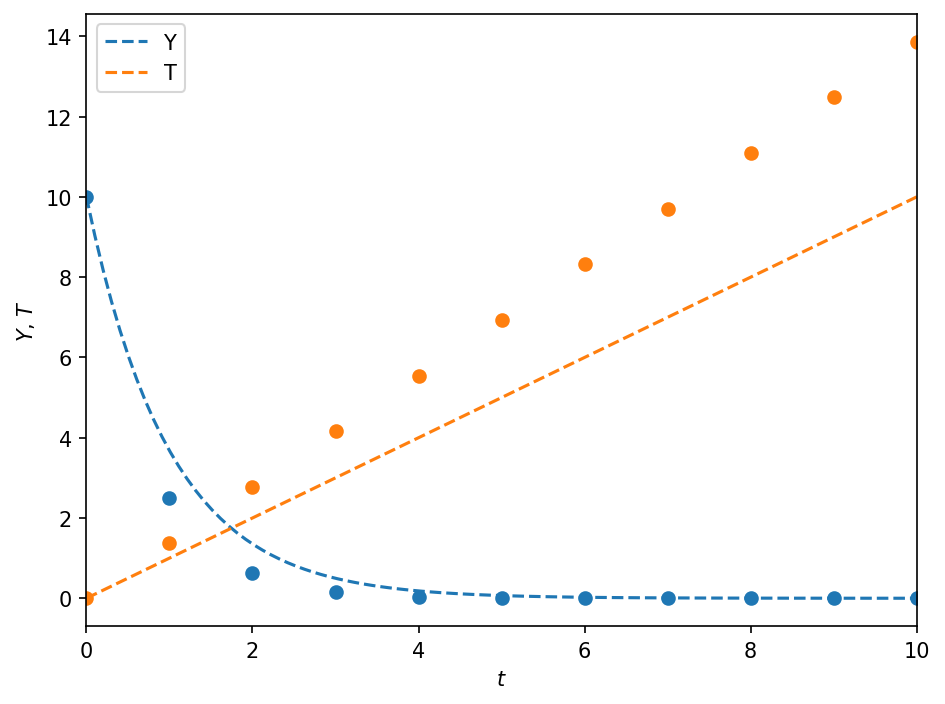

In [45]:
tt = np.linspace(t.min(), t.max(), 100)
fig, ax = plt.subplots()
ax.plot(t, Y, "o", c="C0")
ax.plot(t, T, "o", c="C1")
ax.plot(tt, sim.pars.A*np.exp(-sim.pars.b*tt), "--", c="C0", label="Y")
ax.plot(tt, tt, "--", c="C1", label="T")
ax.set_xlabel("$t$")
ax.set_ylabel("$Y$, $T$")
ax.set_xlim(t.min(), t.max())
ax.legend()
fig.set_layout_engine("tight")

There is significant deviation from the the true solution.

As a little exercise you can try to run this notebook again and try to improve the solution by either choosing a shorter time step or by using a higher order integration scheme. Try, for example, the 4th order explicit Runge-Kutta method.

In [46]:
schemes.expl_4_runge_kutta

simframe.integration.schemes.expl_4_runge_kutta.expl_4_runge_kutta